In [19]:
#@title 0) setup
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1) Multi-Query / Grouped-Query Attention from Scratch

In [20]:
# size constants
batch_size = 1
sequence_length = 8
embedding_size = 12     # must be divisible by n_query_heads
n_query_heads = 3       # number of query heads
n_kv_heads = 1          # KV heads (1=MQA, <n_q=GQA, ==n_q=MHA)
head_dim = embedding_size // n_query_heads   # 4
n_groups = n_query_heads // n_kv_heads       # 3 query heads share 1 KV head

print(f"embedding_size={embedding_size}, n_query_heads={n_query_heads}, "
      f"n_kv_heads={n_kv_heads}, head_dim={head_dim}, n_groups={n_groups}")

embedding_size=12, n_query_heads=3, n_kv_heads=1, head_dim=4, n_groups=3


In [21]:
# 1. Inputs
x = torch.randn(batch_size, sequence_length, embedding_size)

# 2. Projection matrices
#    Q projects to ALL query heads; K,V project to fewer KV heads
W_q = torch.randn(embedding_size, n_query_heads * head_dim)   # (12, 12)
W_k = torch.randn(embedding_size, n_kv_heads  * head_dim)     # (12, 4)
W_v = torch.randn(embedding_size, n_kv_heads  * head_dim)     # (12, 4)

# 3. Project
Q = x @ W_q   # (B, T, n_query_heads * head_dim)
K = x @ W_k   # (B, T, n_kv_heads  * head_dim)
V = x @ W_v   # (B, T, n_kv_heads  * head_dim)

# 4. Reshape into heads
B, T, _ = x.shape
Q = Q.view(B, T, n_query_heads, head_dim).transpose(1, 2)  # (B, n_q, T, d)
K = K.view(B, T, n_kv_heads,   head_dim).transpose(1, 2)   # (B, n_kv, T, d)
V = V.view(B, T, n_kv_heads,   head_dim).transpose(1, 2)   # (B, n_kv, T, d)

# 5. Expand KV heads to match query heads  (the core GQA trick)
#    Each KV head is shared by (n_groups) query heads
K = K.repeat_interleave(n_groups, dim=1)   # (B, n_q, T, d)
V = V.repeat_interleave(n_groups, dim=1)   # (B, n_q, T, d)

# 6. Scaled dot-product attention
scores = (Q @ K.transpose(-2, -1)) / math.sqrt(head_dim)

# 7. Causal mask
mask = torch.triu(torch.ones(T, T), diagonal=1).bool()
scores = scores.masked_fill(mask, float("-inf"))

# 8. Softmax -> weighted sum
attn_weights = F.softmax(scores, dim=-1)
head_outputs = attn_weights @ V                            # (B, n_q, T, d)

# 9. Concatenate heads -> final output
output = head_outputs.transpose(1, 2).contiguous().view(B, T, embedding_size)

In [22]:
# --- Display Results ---
print(f"Input shape:    {x.shape}")
print(f"Q shape:        {Q.shape}  # (B, n_query_heads, T, head_dim)")
print(f"K shape (exp):  {K.shape}  # expanded to match Q")
print(f"V shape (exp):  {V.shape}")
print(f"Scores shape:   {scores.shape}")
print(f"Output shape:   {output.shape}\n")

print("Causal Mask (1 = blocked):")
print(mask.int())

print("\nAttention Weights (Batch 0, Head 0):")
print(attn_weights[0, 0].detach().numpy().round(3))

Input shape:    torch.Size([1, 8, 12])
Q shape:        torch.Size([1, 3, 8, 4])  # (B, n_query_heads, T, head_dim)
K shape (exp):  torch.Size([1, 3, 8, 4])  # expanded to match Q
V shape (exp):  torch.Size([1, 3, 8, 4])
Scores shape:   torch.Size([1, 3, 8, 8])
Output shape:   torch.Size([1, 8, 12])

Causal Mask (1 = blocked):
tensor([[0, 1, 1, 1, 1, 1, 1, 1],
        [0, 0, 1, 1, 1, 1, 1, 1],
        [0, 0, 0, 1, 1, 1, 1, 1],
        [0, 0, 0, 0, 1, 1, 1, 1],
        [0, 0, 0, 0, 0, 1, 1, 1],
        [0, 0, 0, 0, 0, 0, 1, 1],
        [0, 0, 0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 0, 0, 0]], dtype=torch.int32)

Attention Weights (Batch 0, Head 0):
[[1.    0.    0.    0.    0.    0.    0.    0.   ]
 [1.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.999 0.    0.001 0.    0.    0.    0.    0.   ]
 [0.981 0.007 0.    0.012 0.    0.    0.    0.   ]
 [0.003 0.    0.996 0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    1.    0.    0.   ]
 [0.    0.632 0.    0.005 0.363 0.  

Config: n_query_heads=3, n_kv_heads=1 -> Multi-Query Attention (MQA)


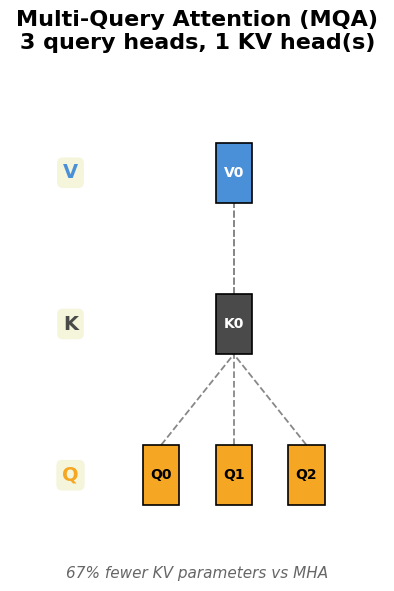

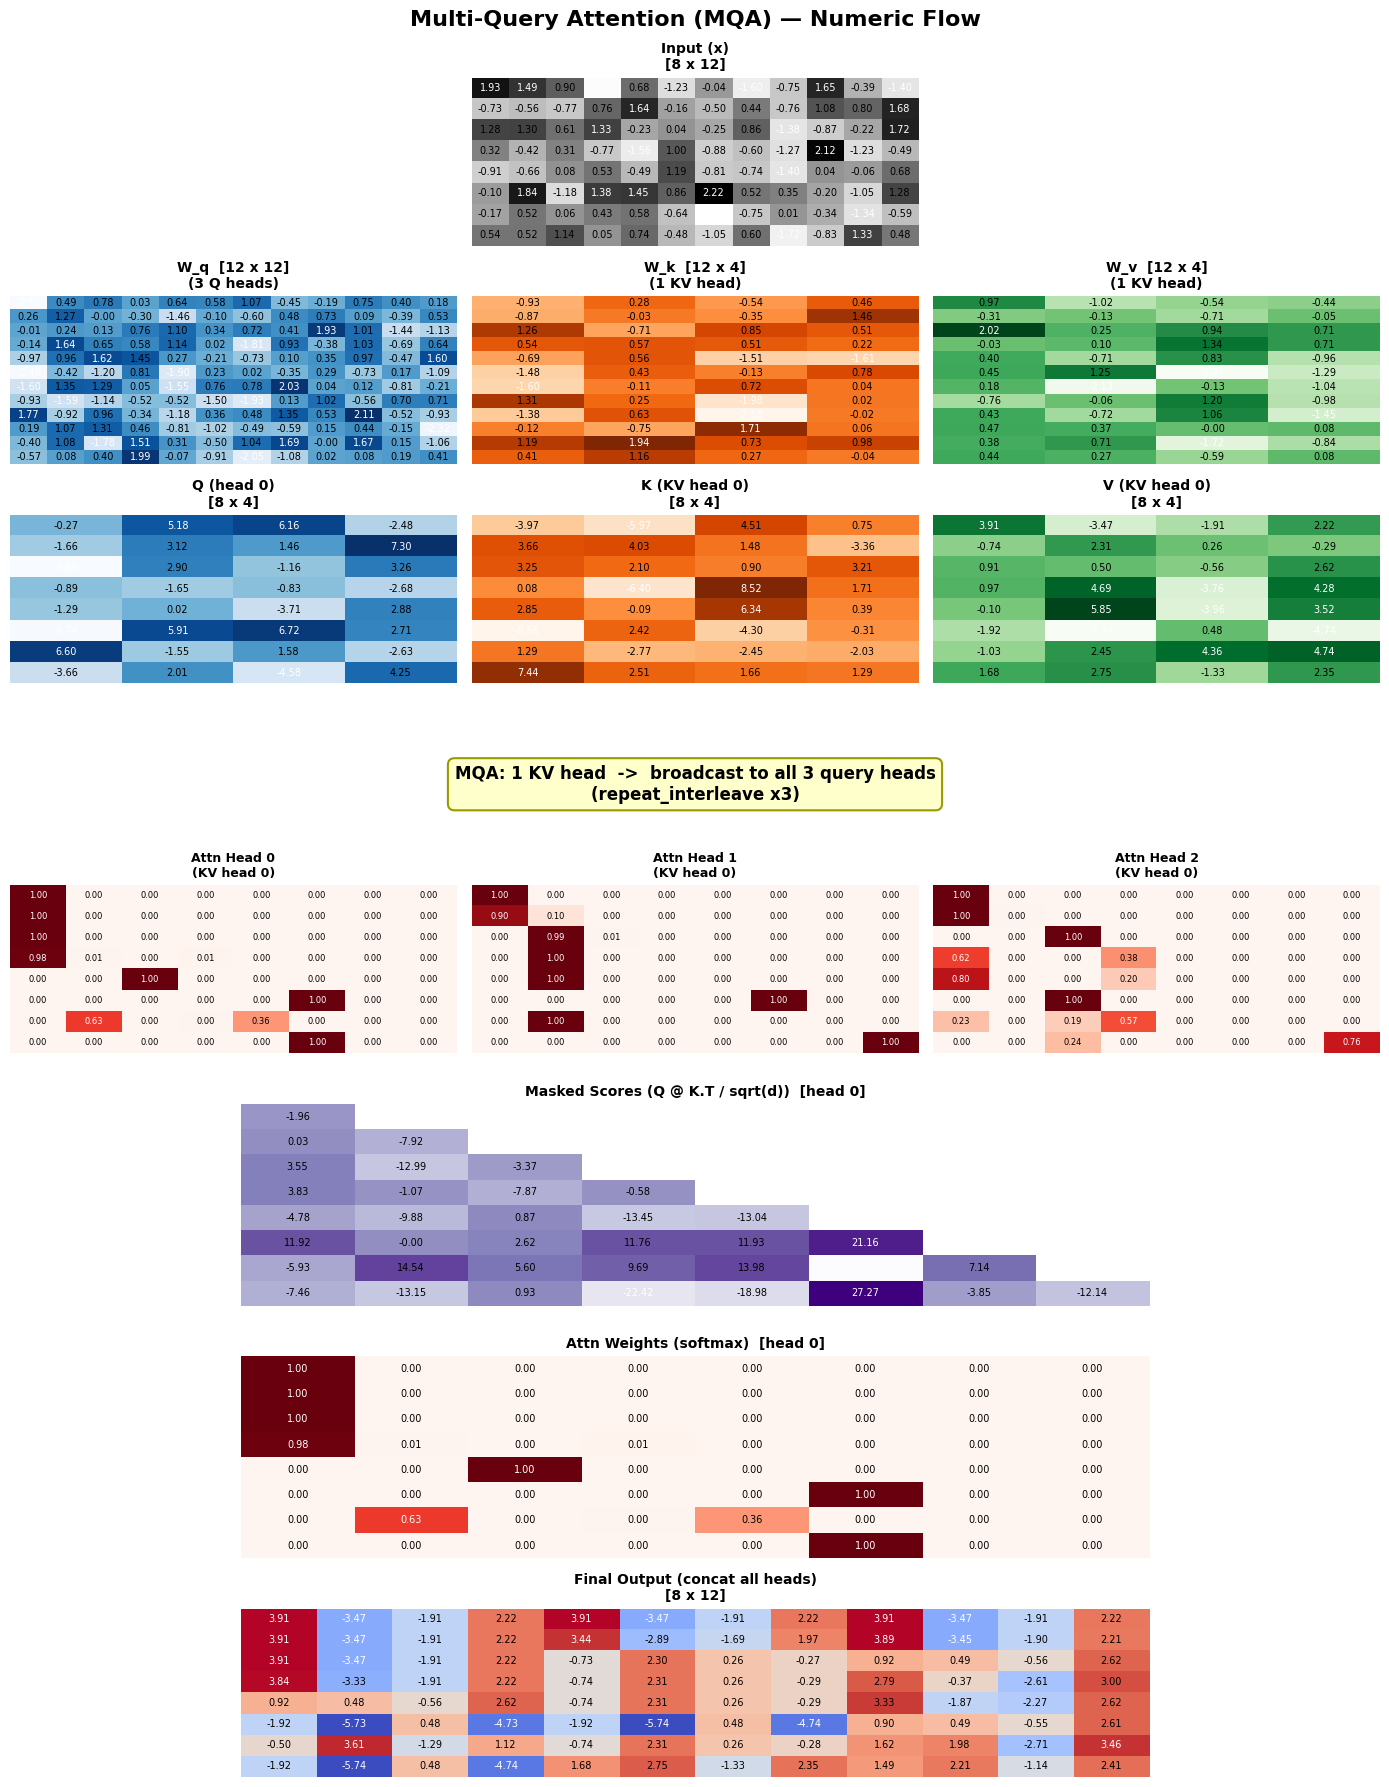

In [23]:
#@title Visualize attention architecture & step-by-step flow

# =====================================================================
# Determine the attention variant from the parameters
# =====================================================================
if n_kv_heads == n_query_heads:
    attn_type = "Multi-Head Attention (MHA)"
elif n_kv_heads == 1:
    attn_type = "Multi-Query Attention (MQA)"
else:
    attn_type = f"Grouped-Query Attention (GQA)"

print(f"Config: n_query_heads={n_query_heads}, n_kv_heads={n_kv_heads} -> {attn_type}")

# =====================================================================
# FIGURE 1: Architecture diagram  (like the MQA | GQA | MHA reference)
# =====================================================================
fig_arch, ax = plt.subplots(figsize=(max(6, n_query_heads * 1.5 + 2), 6))

bar_w = 0.6
bar_h = 1.0
gap_x = 1.2          # horizontal spacing between heads
layer_y = {"Q": 0, "K": 2.5, "V": 5.0}  # vertical positions

# ----- draw query heads (orange) -----
q_xs = [i * gap_x for i in range(n_query_heads)]
# center the whole thing
offset = (max(q_xs) if q_xs else 0) / 2
q_xs = [x - offset for x in q_xs]

for i, qx in enumerate(q_xs):
    rect = plt.Rectangle((qx - bar_w/2, layer_y["Q"]), bar_w, bar_h,
                          fc="#F5A623", ec="black", lw=1.2, zorder=3)
    ax.add_patch(rect)
    ax.text(qx, layer_y["Q"] + bar_h/2, f"Q{i}", ha="center", va="center",
            fontweight="bold", fontsize=10, zorder=4)

# ----- draw KV heads (K=dark, V=blue) -----
# position KV heads centered over their query group
kv_xs = []
for g in range(n_kv_heads):
    # queries in this group
    group_start = g * n_groups
    group_end = group_start + n_groups
    group_q_xs = q_xs[group_start:group_end]
    kv_x = sum(group_q_xs) / len(group_q_xs)  # center of group
    kv_xs.append(kv_x)

for i, kx in enumerate(kv_xs):
    # Key
    rect_k = plt.Rectangle((kx - bar_w/2, layer_y["K"]), bar_w, bar_h,
                            fc="#4A4A4A", ec="black", lw=1.2, zorder=3)
    ax.add_patch(rect_k)
    ax.text(kx, layer_y["K"] + bar_h/2, f"K{i}", ha="center", va="center",
            fontweight="bold", fontsize=10, color="white", zorder=4)
    # Value
    rect_v = plt.Rectangle((kx - bar_w/2, layer_y["V"]), bar_w, bar_h,
                            fc="#4A90D9", ec="black", lw=1.2, zorder=3)
    ax.add_patch(rect_v)
    ax.text(kx, layer_y["V"] + bar_h/2, f"V{i}", ha="center", va="center",
            fontweight="bold", fontsize=10, color="white", zorder=4)

# ----- draw dashed connection lines from Q -> K -----
for qi in range(n_query_heads):
    kv_idx = qi // n_groups
    qx = q_xs[qi]
    kx = kv_xs[kv_idx]

    # Q top -> K bottom
    ax.plot([qx, kx], [layer_y["Q"] + bar_h, layer_y["K"]],
            ls="--", color="#888888", lw=1.3, zorder=1)
    # K top -> V bottom
    ax.plot([kx, kx], [layer_y["K"] + bar_h, layer_y["V"]],
            ls="--", color="#888888", lw=1.3, zorder=1)

# ----- labels on the left -----
label_x = min(q_xs) - bar_w/2 - 1.2
for name, y in layer_y.items():
    color = {"Q": "#F5A623", "K": "#4A4A4A", "V": "#4A90D9"}[name]
    ax.text(label_x, y + bar_h/2, name, ha="center", va="center",
            fontsize=14, fontweight="bold", color=color,
            bbox=dict(boxstyle="round,pad=0.3", fc="#F5F5DC", ec="none"))

# ----- title & styling -----
ax.set_xlim(label_x - 1, max(q_xs) + bar_w/2 + 1)
ax.set_ylim(-0.8, layer_y["V"] + bar_h + 1.2)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title(f"{attn_type}\n{n_query_heads} query heads, {n_kv_heads} KV head(s)",
             fontsize=16, fontweight="bold", pad=15)

# subtitle with param savings
if n_kv_heads < n_query_heads:
    savings = (1 - n_kv_heads / n_query_heads) * 100
    ax.text(0.5, -0.05, f"{savings:.0f}% fewer KV parameters vs MHA",
            transform=ax.transAxes, ha="center", fontsize=11, style="italic", color="#666")

plt.tight_layout()
plt.show()

# =====================================================================
# FIGURE 2: Numeric flow (adapted from original visualization)
# =====================================================================
fig = plt.figure(figsize=(14, 18))
gs = fig.add_gridspec(8, 6, height_ratios=[1, 1, 1, 0.6, 1, 1.2, 1.2, 1])

ax_x = fig.add_subplot(gs[0, 2:4])

ax_Wq = fig.add_subplot(gs[1, 0:2])
ax_Wk = fig.add_subplot(gs[1, 2:4])
ax_Wv = fig.add_subplot(gs[1, 4:6])

ax_Q = fig.add_subplot(gs[2, 0:2])
ax_K = fig.add_subplot(gs[2, 2:4])
ax_V = fig.add_subplot(gs[2, 4:6])

ax_expand = fig.add_subplot(gs[3, 1:5])

ax_heads = [fig.add_subplot(gs[4, i*2:(i+1)*2]) for i in range(min(n_query_heads, 3))]

ax_scores = fig.add_subplot(gs[5, 1:5])
ax_weights = fig.add_subplot(gs[6, 1:5])
ax_out = fig.add_subplot(gs[7, 1:5])

def plot_annotated(ax, tensor, title, cmap):
    if tensor.dim() == 4:
        mat = tensor[0, 0].detach().numpy()
    elif tensor.dim() == 3:
        mat = tensor[0].detach().numpy()
    else:
        mat = tensor.detach().numpy()
    mat_vis = np.where(np.isinf(mat), np.nan, mat)
    ax.imshow(mat_vis, cmap=cmap, aspect='auto')
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.axis('off')
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat[i, j]
            txt = "-inf" if np.isinf(val) else f"{val:.2f}"
            ax.text(j, i, txt, ha="center", va="center",
                    color="white" if (not np.isnan(val) and abs(val) > np.nanmax(np.abs(mat_vis))*0.6) else "black",
                    fontsize=7)

plot_annotated(ax_x, x, f"Input (x)\n[{sequence_length} x {embedding_size}]", "Greys")

plot_annotated(ax_Wq, W_q, f"W_q  [{embedding_size} x {n_query_heads*head_dim}]\n({n_query_heads} Q heads)", "Blues")
plot_annotated(ax_Wk, W_k, f"W_k  [{embedding_size} x {n_kv_heads*head_dim}]\n({n_kv_heads} KV head{'s' if n_kv_heads>1 else ''})", "Oranges")
plot_annotated(ax_Wv, W_v, f"W_v  [{embedding_size} x {n_kv_heads*head_dim}]\n({n_kv_heads} KV head{'s' if n_kv_heads>1 else ''})", "Greens")

plot_annotated(ax_Q, Q[:, 0], f"Q (head 0)\n[{sequence_length} x {head_dim}]", "Blues")
plot_annotated(ax_K, K[:, 0], f"K (KV head 0)\n[{sequence_length} x {head_dim}]", "Oranges")
plot_annotated(ax_V, V[:, 0], f"V (KV head 0)\n[{sequence_length} x {head_dim}]", "Greens")

# Expand annotation — adapts to the config
ax_expand.axis("off")
if n_kv_heads == n_query_heads:
    expand_txt = f"MHA: each query head has its own KV head (no sharing)"
    expand_color = "#d4edda"
    expand_ec = "#28a745"
elif n_kv_heads == 1:
    expand_txt = (f"MQA: 1 KV head  ->  broadcast to all {n_query_heads} query heads\n"
                  f"(repeat_interleave x{n_groups})")
    expand_color = "#ffffcc"
    expand_ec = "#999900"
else:
    expand_txt = (f"GQA: {n_kv_heads} KV heads  ->  {n_groups} query heads each\n"
                  f"(repeat_interleave x{n_groups})")
    expand_color = "#fff3cd"
    expand_ec = "#d4a017"

ax_expand.text(0.5, 0.5, expand_txt,
    ha="center", va="center", fontsize=12, fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.4", fc=expand_color, ec=expand_ec, lw=1.5))

for h_idx, ax_h in enumerate(ax_heads):
    w = attn_weights[0, h_idx].detach().numpy()
    ax_h.imshow(w, cmap="Reds", vmin=0, aspect="auto")
    kv_grp = h_idx // n_groups
    ax_h.set_title(f"Attn Head {h_idx}\n(KV head {kv_grp})", fontweight="bold", fontsize=9)
    ax_h.axis("off")
    for i in range(w.shape[0]):
        for j in range(w.shape[1]):
            v = w[i, j]
            ax_h.text(j, i, f"{v:.2f}", ha="center", va="center",
                      color="white" if v > 0.5 else "black", fontsize=6)

plot_annotated(ax_scores, scores[:, 0], "Masked Scores (Q @ K.T / sqrt(d))  [head 0]", "Purples")
plot_annotated(ax_weights, attn_weights[:, 0], "Attn Weights (softmax)  [head 0]", "Reds")
plot_annotated(ax_out, output, f"Final Output (concat all heads)\n[{sequence_length} x {embedding_size}]", "coolwarm")

fig.suptitle(f"{attn_type} — Numeric Flow", fontsize=16, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()

# 2) PyTorch Module

In [24]:
class CausalSelfAttention(nn.Module):
    """Single-head causal (masked) self-attention."""

    def __init__(self, embedding_size: int, head_dimension: int, max_seq_len: int = 1024):
        super().__init__()
        self.head_dimension = head_dimension
        self.W_q = nn.Linear(embedding_size, head_dimension, bias=False)
        self.W_k = nn.Linear(embedding_size, head_dimension, bias=False)
        self.W_v = nn.Linear(embedding_size, head_dimension, bias=False)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(max_seq_len, max_seq_len), diagonal=1).bool(),
        )

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        B, T, _ = x.shape
        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)
        scores = Q @ K.transpose(-2, -1) / math.sqrt(self.head_dimension)
        scores = scores.masked_fill(self.mask[:T, :T], float("-inf"))
        attn_weights = F.softmax(scores, dim=-1)
        output = attn_weights @ V
        return output, attn_weights

In [25]:
class GroupedQueryAttention(nn.Module):
    """Grouped-Query Attention (GQA) with causal masking.

    n_kv_heads == n_query_heads  : standard MHA
    n_kv_heads == 1              : Multi-Query Attention (MQA)
    otherwise                    : GQA
    """

    def __init__(
        self,
        embedding_size: int,
        n_query_heads: int,
        n_kv_heads: int,
        max_seq_len: int = 1024,
    ):
        super().__init__()
        assert embedding_size % n_query_heads == 0, \
            "embedding_size must be divisible by n_query_heads"
        assert n_query_heads % n_kv_heads == 0, \
            "n_query_heads must be divisible by n_kv_heads"

        self.n_query_heads = n_query_heads
        self.n_kv_heads = n_kv_heads
        self.head_dim = embedding_size // n_query_heads
        self.n_groups = n_query_heads // n_kv_heads

        # Separate projections for clarity (production code fuses these)
        self.W_q = nn.Linear(embedding_size, n_query_heads * self.head_dim, bias=False)
        self.W_k = nn.Linear(embedding_size, n_kv_heads  * self.head_dim, bias=False)
        self.W_v = nn.Linear(embedding_size, n_kv_heads  * self.head_dim, bias=False)
        self.out_proj = nn.Linear(embedding_size, embedding_size, bias=False)

        self.register_buffer(
            "mask",
            torch.triu(torch.ones(max_seq_len, max_seq_len), diagonal=1).bool(),
        )

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        B, T, _ = x.shape

        # Project
        Q = self.W_q(x).view(B, T, self.n_query_heads, self.head_dim).transpose(1, 2)
        K = self.W_k(x).view(B, T, self.n_kv_heads,    self.head_dim).transpose(1, 2)
        V = self.W_v(x).view(B, T, self.n_kv_heads,    self.head_dim).transpose(1, 2)

        # Expand KV heads: repeat each KV head for its group of query heads
        K = K.repeat_interleave(self.n_groups, dim=1)  # (B, n_q, T, d)
        V = V.repeat_interleave(self.n_groups, dim=1)

        # Scaled dot-product + causal mask
        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(self.head_dim)
        scores = scores.masked_fill(self.mask[:T, :T], float("-inf"))
        attn_weights = F.softmax(scores, dim=-1)
        out = attn_weights @ V

        # Merge heads and project
        out = out.transpose(1, 2).contiguous().view(B, T, -1)
        return self.out_proj(out), attn_weights

In [26]:
# quick smoke test -- 3 query heads, 1 KV head (MQA), 1 layer
n_q, n_kv = 3, 1
gqa = GroupedQueryAttention(embedding_size=embedding_size,
                            n_query_heads=n_q, n_kv_heads=n_kv)
x = torch.randn(batch_size, sequence_length, embedding_size)

out, attn = gqa(x)
print(f"output: {out.shape}  # (batch, seq_len, embedding_size)")
print(f"Attn maps:  {attn.shape}  # (batch, n_query_heads, T, T)")
print(f"\nRow sums (should be 1.0): {attn[0, 0].sum(dim=-1).detach().numpy().round(4)}")
print(f"\nKV savings: {n_kv} KV head vs {n_q} query heads "
      f"-> {(1 - n_kv/n_q)*100:.0f}% fewer KV parameters")

output: torch.Size([1, 8, 12])  # (batch, seq_len, embedding_size)
Attn maps:  torch.Size([1, 3, 8, 8])  # (batch, n_query_heads, T, T)

Row sums (should be 1.0): [1. 1. 1. 1. 1. 1. 1. 1.]

KV savings: 1 KV head vs 3 query heads -> 67% fewer KV parameters


# 3) Mechanistic Interpretability: Attention in Qwen2-0.5B, ad-hoc visualization

Qwen2-0.5B uses **Grouped-Query Attention** with 14 query heads and 2 KV heads per layer (7 query heads per KV group). Change `n_kv_heads` in Section 1 to 1, 2, or 3 to see how the architecture diagram adapts between MQA, GQA, and MHA.

In [27]:
from transformers import AutoTokenizer, AutoModel

model_name = "Qwen/Qwen2-0.5B"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name, output_attentions=True).eval().to(device)

cfg = model.config
print(f"Qwen2-0.5B config: {cfg.num_hidden_layers} layers, "
      f"{cfg.num_attention_heads} query heads, "
      f"{cfg.num_key_value_heads} KV heads, "
      f"d_model={cfg.hidden_size}")
print(f"  -> {cfg.num_attention_heads // cfg.num_key_value_heads} query heads per KV group (GQA)")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Qwen2-0.5B config: 24 layers, 14 query heads, 2 KV heads, d_model=896
  -> 7 query heads per KV group (GQA)


In [28]:
# a sentence with clear syntactic structure for interpretability
prompt = "When Mary and John went to the store, John gave a drink to Mary."

inputs = tokenizer(prompt, return_tensors="pt").to(device)
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

with torch.no_grad():
    outputs = model(**inputs)

# outputs.attentions is a tuple of (1, n_query_heads, T, T) -- one per layer
# HuggingFace already broadcasts KV heads internally, so attention maps
# are returned at the query-head granularity
attentions = torch.cat(outputs.attentions, dim=0).float()  # (n_layers, n_query_heads, T, T)
print(f"Attention tensor: {attentions.shape}  # (layers, query_heads, query_pos, key_pos)")
print(f"Tokens: {tokens}")

Attention tensor: torch.Size([24, 14, 16, 16])  # (layers, query_heads, query_pos, key_pos)
Tokens: ['When', 'ĠMary', 'Ġand', 'ĠJohn', 'Ġwent', 'Ġto', 'Ġthe', 'Ġstore', ',', 'ĠJohn', 'Ġgave', 'Ġa', 'Ġdrink', 'Ġto', 'ĠMary', '.']


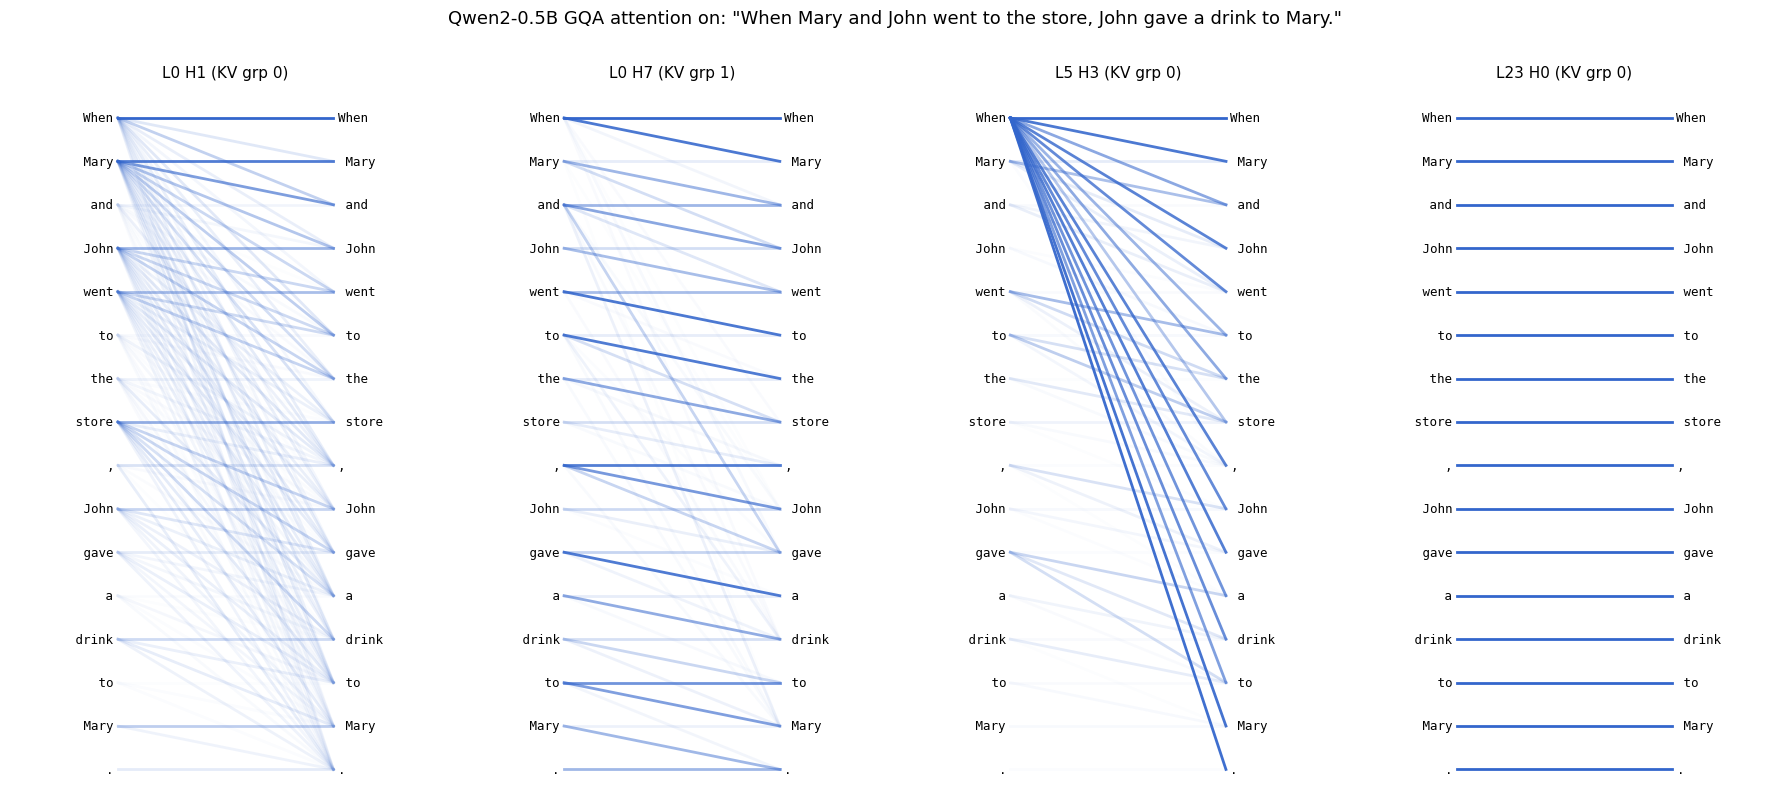

In [29]:
#@title visualize interesting attention heads
# Pick a few heads from different layers/KV groups
n_heads_total = attentions.shape[1]
interesting = [(0, 1), (0, 7), (5, 3), (cfg.num_hidden_layers - 1, 0)]

def plot_attention(attn, tokens, layer, head, ax=None):
    """
    Draws lines from every destination (query) token to every source (key)
    token, with opacity proportional to the attention weight.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 8))

    weights = attn[layer, head].cpu().float().numpy()
    n = len(tokens)
    labels = [t.replace("Ġ", " ").replace("Ċ", "\\n") for t in tokens]

    x_src, x_dst = 0.0, 1.0
    for i in range(n):
        y = 1 - i / (n - 1)
        ax.text(x_src - 0.02, y, labels[i], ha="right", va="center", fontsize=9, fontfamily="monospace")
        ax.text(x_dst + 0.02, y, labels[i], ha="left",  va="center", fontsize=9, fontfamily="monospace")

    for dst in range(n):
        for src in range(dst + 1):
            w = weights[dst, src]
            if w < 0.01:
                continue
            y_dst = 1 - dst / (n - 1)
            y_src = 1 - src / (n - 1)
            ax.plot([x_src, x_dst], [y_src, y_dst],
                    color="#3366cc", alpha=float(w), linewidth=2)

    kv_group = head // (cfg.num_attention_heads // cfg.num_key_value_heads)
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.05, 1.05)
    ax.axis("off")
    ax.set_title(f"L{layer} H{head} (KV grp {kv_group})", fontsize=11)


fig, axes = plt.subplots(1, 4, figsize=(18, 8))
for ax, (l, h) in zip(axes, interesting):
    plot_attention(attentions, tokens, l, h, ax=ax)
fig.suptitle(f'Qwen2-0.5B GQA attention on: "{prompt}"', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

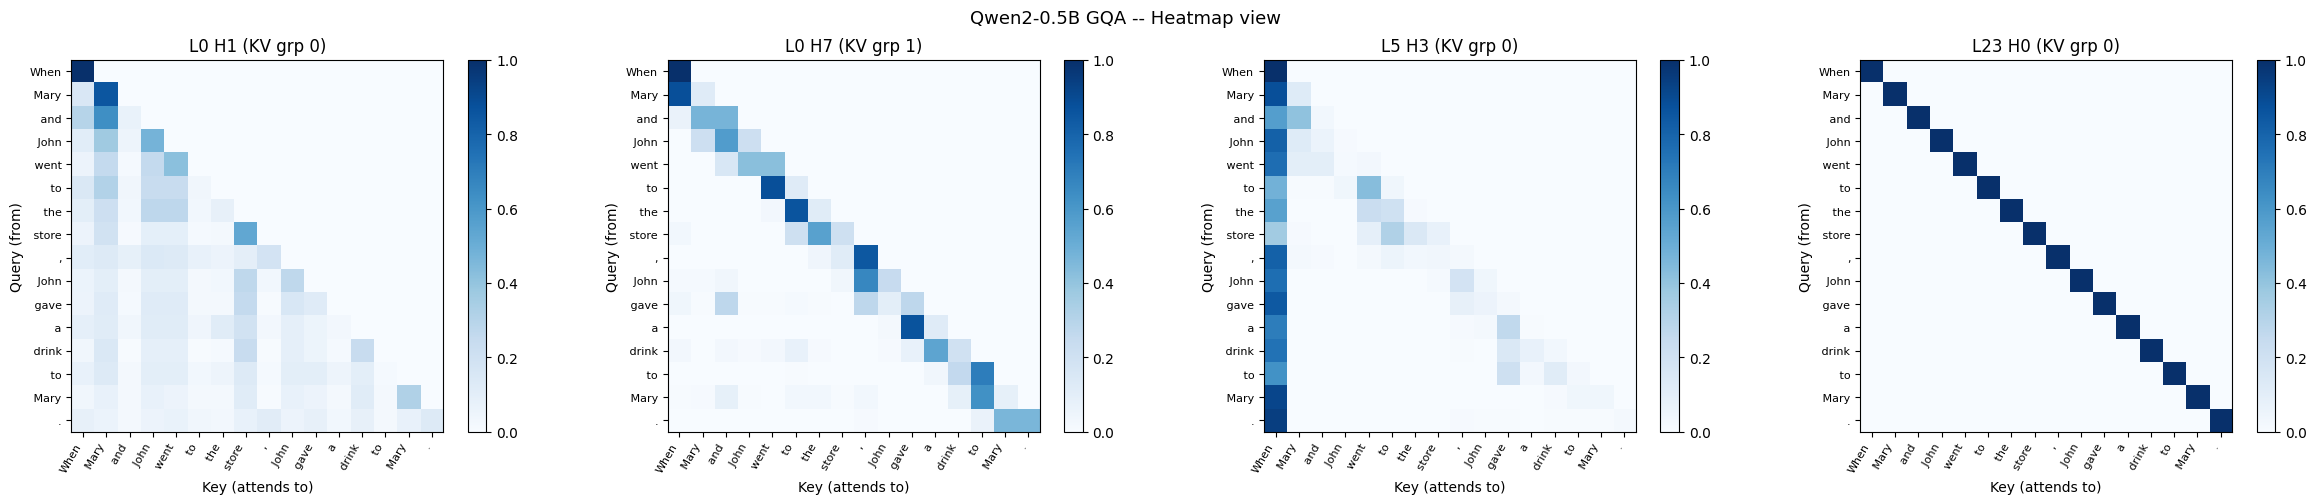

In [30]:
# --- 4a. Classic heatmap ---

def plot_attention_heatmap(attn, tokens, layer, head, ax=None):
    """Standard heatmap of the attention matrix."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    labels = [t.replace("Ġ", " ") for t in tokens]
    weights = attn[layer, head].cpu().float().numpy()
    im = ax.imshow(weights, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=60, ha="right", fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel("Key (attends to)")
    ax.set_ylabel("Query (from)")
    kv_group = head // (cfg.num_attention_heads // cfg.num_key_value_heads)
    ax.set_title(f"L{layer} H{head} (KV grp {kv_group})")
    plt.colorbar(im, ax=ax, fraction=0.046)

fig, axes = plt.subplots(1, 4, figsize=(24, 5))
for ax, (l, h) in zip(axes, interesting):
    plot_attention_heatmap(attentions, tokens, l, h, ax=ax)
fig.suptitle("Qwen2-0.5B GQA -- Heatmap view", fontsize=13)
plt.tight_layout()
plt.show()

# 5) BertViz: Visualizing attention heads

[BertViz](https://github.com/jessevig/bertviz) (Jesse Vig)

In [31]:
!pip install bertviz -q

In [32]:
from bertviz import head_view, model_view
from transformers import AutoTokenizer, AutoModel

# bertviz works with HuggingFace models -- use Qwen2-0.5B (GQA)
bv_model_name = "Qwen/Qwen2-0.5B"
bv_tokenizer = AutoTokenizer.from_pretrained(bv_model_name)
bv_model = AutoModel.from_pretrained(bv_model_name, output_attentions=True).eval()

bv_prompt = "When Mary and John went to the store, John gave a drink to Mary."
bv_inputs = bv_tokenizer(bv_prompt, return_tensors="pt")
bv_tokens = bv_tokenizer.convert_ids_to_tokens(bv_inputs["input_ids"][0])

with torch.no_grad():
    bv_outputs = bv_model(**bv_inputs)

bv_attention = bv_outputs.attentions  # tuple of (1, n_query_heads, T, T)
print(f"Ready: {len(bv_attention)} layers, {bv_attention[0].shape[1]} query heads, tokens = {bv_tokens}")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Ready: 24 layers, 14 query heads, tokens = ['When', 'ĠMary', 'Ġand', 'ĠJohn', 'Ġwent', 'Ġto', 'Ġthe', 'Ġstore', ',', 'ĠJohn', 'Ġgave', 'Ġa', 'Ġdrink', 'Ġto', 'ĠMary', '.']


In [33]:
# MODEL VIEW -- compact overview of every layer and head
# click any cell to see the full attention pattern
model_view(bv_attention, bv_tokens)

<IPython.core.display.Javascript object>